In [1]:
library(Seurat)
library(dplyr)
library(clusterProfiler)
# single-cell analysis package
library(dplyr)
library(dittoSeq)
library(reticulate)

# plotting and data science packages
library(tidyverse)
library(cowplot)
library(patchwork)
library(org.Hs.eg.db)

library(enrichplot)
library(GOSemSim)
library(escape)
    library(future)
    library(data.table)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages

## GO terms

In [2]:
nmf_modules <- as.data.frame(readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds'))
nmf_modules

MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12,MP_13
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
DIAPH3,ACTG1,GBE1,RIPOR2,CTNND2,DSCAM,CCL3,F13A1,MYO1E,ANKUB1,CHORDC1,NBEA,JAZF1
CENPK,ATP5F1E,HK2,FCN1,NPAS3,NAV3,CD83,MRC1,GAS7,SLC35G2,HSPD1,RFX3,MEF2C
POLQ,C1QC,PAM,GLT1D1,LSAMP,FOXP2,NR4A1,COLEC12,GPNMB,ATP8B1,HSPH1,CLASP2,PCNX2
KNL1,CST3,CD109,PLCB1,MAP2,SYNDIG1,CCL4,LYVE1,LPL,FAM177B,BAG3,MSRA,AOAH
MELK,FAU,NDRG1,SLCO3A1,ADGRL3,HS3ST4,NR4A2,CD163,ASAP1,P2RY13,CACYBP,PHF14,EPB41L2
TOP2A,PTMA,TNS1,SVIL,RORA,CACNA1D,CCL4L2,DAPK1,GLDN,PLAT,DNAJB1,CAMTA1,PRKN
BRIP1,CD63,FNIP2,VCAN,GPM6A,MCF2L,EGR3,SELENOP,HIVEP1,PTPRB,DNAJB4,CASK,ZDHHC14
CIT,FTL,GPNMB,MEGF9,LRP1B,RASGEF1C,IRAK2,THRB,MITF,SHOC1,HSPA1A,GAB1,BLNK
RRM2,S100A11,PLIN2,FYN,PCDH9,TLN2,NFKBID,CD163L1,PTPRG,C11ORF65,HSPA1B,MAP4K5,CSGALNACT1


In [17]:
ego <- enrichGO(gene          = nmf_modules[[2]],,
                # universe      = rownames(myeloid),
                OrgDb         = org.Hs.eg.db,
                keyType = 'SYMBOL',
                ont           = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
        readable      = TRUE)
head(ego, n=30)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0002396,GO:0002396,MHC protein complex assembly,6/50,20/18870,9.558831e-12,7.976845e-09,4.900159e-09,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1/CALR,6
GO:0002501,GO:0002501,peptide antigen assembly with MHC protein complex,6/50,20/18870,9.558831e-12,7.976845e-09,4.900159e-09,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1/CALR,6
GO:0051251,GO:0051251,positive regulation of lymphocyte activation,12/50,330/18870,4.488281e-11,2.496980e-08,1.533890e-08,CD81/ACTB/HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/TYROBP/AIF1/LGALS1/MIF/HLA-DPB1/CD74,12
GO:0019886,GO:0019886,antigen processing and presentation of exogenous peptide antigen via MHC class II,6/50,31/18870,1.776247e-10,7.411389e-08,4.552800e-08,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1/CD74,6
GO:0002696,GO:0002696,positive regulation of leukocyte activation,12/50,380/18870,2.280575e-10,7.612560e-08,4.676380e-08,CD81/ACTB/HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/TYROBP/AIF1/LGALS1/MIF/HLA-DPB1/CD74,12
GO:0050867,GO:0050867,positive regulation of cell activation,12/50,396/18870,3.655705e-10,8.426069e-08,5.176116e-08,CD81/ACTB/HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/TYROBP/AIF1/LGALS1/MIF/HLA-DPB1/CD74,12
GO:0002495,GO:0002495,antigen processing and presentation of peptide antigen via MHC class II,6/50,35/18870,3.884580e-10,8.426069e-08,5.176116e-08,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1/CD74,6
GO:0002399,GO:0002399,MHC class II protein complex assembly,5/50,16/18870,4.543716e-10,8.426069e-08,5.176116e-08,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1,5
GO:0002503,GO:0002503,peptide antigen assembly with MHC class II protein complex,5/50,16/18870,4.543716e-10,8.426069e-08,5.176116e-08,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1,5


In [5]:
enr_go <- clusterProfiler::simplify(ego)
View(enr_go@result)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0002396,GO:0002396,MHC protein complex assembly,6/50,20/18870,9.558831e-12,7.976845e-09,4.900159e-09,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1/CALR,6
GO:0002501,GO:0002501,peptide antigen assembly with MHC protein complex,6/50,20/18870,9.558831e-12,7.976845e-09,4.900159e-09,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1/CALR,6
GO:0051251,GO:0051251,positive regulation of lymphocyte activation,12/50,330/18870,4.488281e-11,2.496980e-08,1.533890e-08,CD81/ACTB/HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/TYROBP/AIF1/LGALS1/MIF/HLA-DPB1/CD74,12
GO:0019886,GO:0019886,antigen processing and presentation of exogenous peptide antigen via MHC class II,6/50,31/18870,1.776247e-10,7.411389e-08,4.552800e-08,HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/HLA-DPB1/CD74,6
GO:0050870,GO:0050870,positive regulation of T cell activation,10/50,251/18870,9.334262e-10,1.198376e-07,7.361596e-08,CD81/ACTB/HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/AIF1/LGALS1/HLA-DPB1/CD74,10
GO:1903039,GO:1903039,positive regulation of leukocyte cell-cell adhesion,10/50,275/18870,2.256083e-09,2.689573e-07,1.652199e-07,CD81/ACTB/HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/AIF1/LGALS1/HLA-DPB1/CD74,10
GO:0050863,GO:0050863,regulation of T cell activation,10/50,381/18870,5.008494e-08,4.283570e-06,2.631388e-06,CD81/ACTB/HLA-DRA/B2M/HLA-DPA1/HLA-DRB1/AIF1/LGALS1/HLA-DPB1/CD74,10
GO:0030100,GO:0030100,regulation of endocytosis,9/50,291/18870,6.277224e-08,4.988898e-06,3.064670e-06,ACTG1/CD63/ACTB/APOE/B2M/CD14/APOC1/RACK1/CALR,9
GO:0034341,GO:0034341,response to type II interferon,7/50,143/18870,9.421431e-08,7.147440e-06,4.390657e-06,ACTG1/GAPDH/HLA-DPA1/AIF1/IFITM3/VIM/CD74,7


preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invail

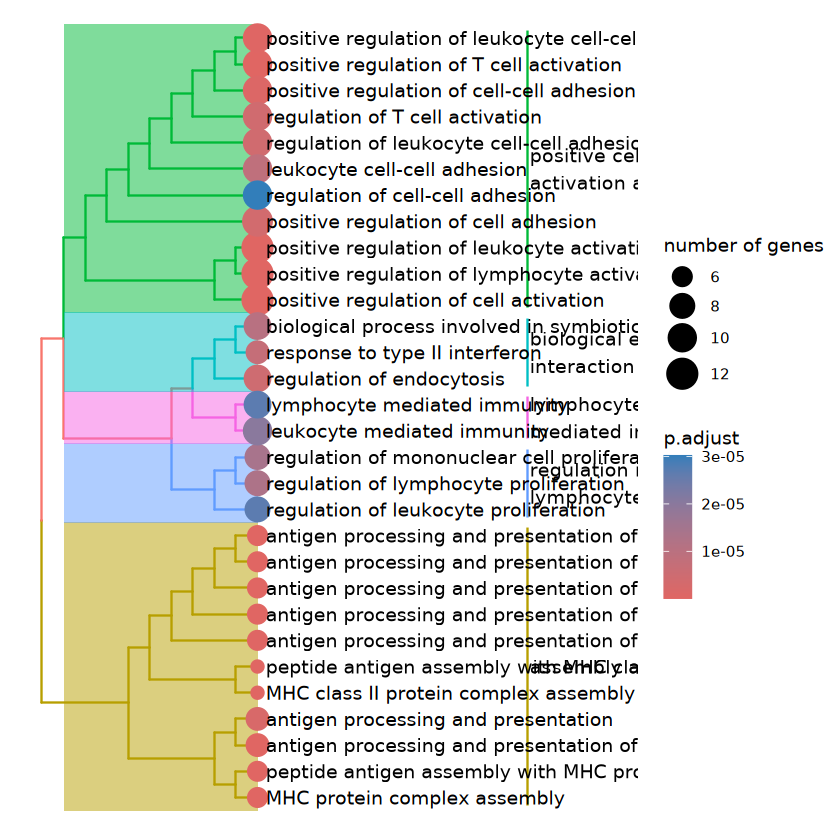

In [18]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego, semData = d)
treeplot(ego2)

Warning message in treeplot.enrichResult(x, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



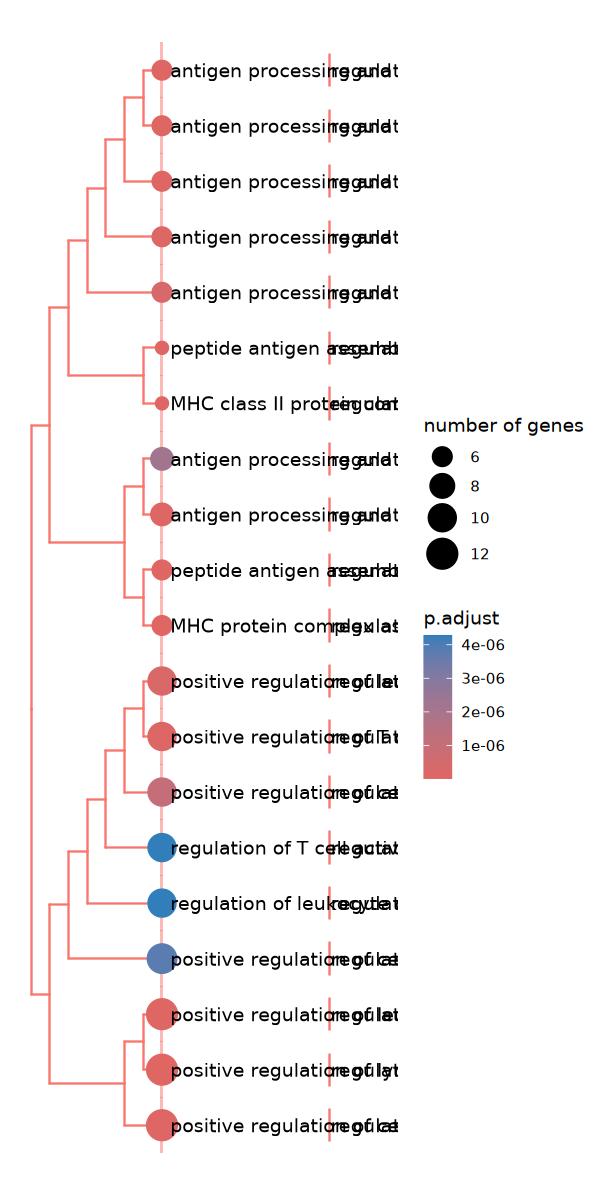

In [19]:
options(repr.plot.height = 10, repr.plot.width = 5)
treeplot(ego2, showCategory = 20, nCluster = 1)

In [21]:
ggsave('figures/go_analysis_myeliod_MP2.pdf', width = 5, height = 7)

In [6]:
pdf("figures/GO_emapplot_MP2.pdf", width = 10, height = 8)  # choose size you like
enrichplot::emapplot(enrichplot::pairwise_termsim(enr_go),
                     showCategory = 20,
                     cex.params = list(category_label = 0.5))
dev.off()

png 
  2

In [22]:
ego <- enrichGO(gene          = nmf_modules[[7]],
                # universe      = rownames(myeloid),
                OrgDb         = org.Hs.eg.db,
                keyType = 'SYMBOL',
                ont           = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
        readable      = TRUE)
head(ego, n=30)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0060326,GO:0060326,cell chemotaxis,10/46,325/18870,4.707989e-09,6.471826e-06,3.790199e-06,CCL3/NR4A1/CCL4/EGR3/CCL3L1/CH25H/CCL2/DUSP1/IL1B/NEDD9,10
GO:0071347,GO:0071347,cellular response to interleukin-1,7/46,111/18870,8.916996e-09,6.471826e-06,3.790199e-06,CCL3/CCL4/IRAK2/CCL3L1/CCL2/EGR1/IL1B,7
GO:0048247,GO:0048247,lymphocyte chemotaxis,6/46,64/18870,1.008596e-08,6.471826e-06,3.790199e-06,CCL3/CCL4/CCL3L1/CH25H/CCL2/NEDD9,6
GO:0002696,GO:0002696,positive regulation of leukocyte activation,10/46,380/18870,2.083242e-08,1.002560e-05,5.871452e-06,CCL3/CD83/EGR3/NFKBID/NR4A3/CCL2/IL1B/TNF/BCL6/CDKN1A,10
GO:0050867,GO:0050867,positive regulation of cell activation,10/46,396/18870,3.074303e-08,1.072225e-05,6.279442e-06,CCL3/CD83/EGR3/NFKBID/NR4A3/CCL2/IL1B/TNF/BCL6/CDKN1A,10
GO:0071674,GO:0071674,mononuclear cell migration,8/46,207/18870,3.342000e-08,1.072225e-05,6.279442e-06,CCL3/CCL4/CCL3L1/CH25H/CCL2/DUSP1/NEDD9/TNF,8
GO:0070555,GO:0070555,response to interleukin-1,7/46,140/18870,4.473432e-08,1.230194e-05,7.204579e-06,CCL3/CCL4/IRAK2/CCL3L1/CCL2/EGR1/IL1B,7
GO:0030595,GO:0030595,leukocyte chemotaxis,8/46,240/18870,1.048032e-07,2.521827e-05,1.476897e-05,CCL3/CCL4/CCL3L1/CH25H/CCL2/DUSP1/IL1B/NEDD9,8
GO:0045930,GO:0045930,negative regulation of mitotic cell cycle,8/46,248/18870,1.348043e-07,2.667425e-05,1.562166e-05,BTG2/TEX14/CCL2/DUSP1/IER3/TNF/BCL6/CDKN1A,8


In [8]:
enr_go <- clusterProfiler::simplify(ego)
View(enr_go@result)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0060326,GO:0060326,cell chemotaxis,10/46,325/18870,4.707989e-09,6.471826e-06,3.790199e-06,CCL3/NR4A1/CCL4/EGR3/CCL3L1/CH25H/CCL2/DUSP1/IL1B/NEDD9,10
GO:0071347,GO:0071347,cellular response to interleukin-1,7/46,111/18870,8.916996e-09,6.471826e-06,3.790199e-06,CCL3/CCL4/IRAK2/CCL3L1/CCL2/EGR1/IL1B,7
GO:0048247,GO:0048247,lymphocyte chemotaxis,6/46,64/18870,1.008596e-08,6.471826e-06,3.790199e-06,CCL3/CCL4/CCL3L1/CH25H/CCL2/NEDD9,6
GO:0002696,GO:0002696,positive regulation of leukocyte activation,10/46,380/18870,2.083242e-08,1.002560e-05,5.871452e-06,CCL3/CD83/EGR3/NFKBID/NR4A3/CCL2/IL1B/TNF/BCL6/CDKN1A,10
GO:0071674,GO:0071674,mononuclear cell migration,8/46,207/18870,3.342000e-08,1.072225e-05,6.279442e-06,CCL3/CCL4/CCL3L1/CH25H/CCL2/DUSP1/NEDD9/TNF,8
GO:0070555,GO:0070555,response to interleukin-1,7/46,140/18870,4.473432e-08,1.230194e-05,7.204579e-06,CCL3/CCL4/IRAK2/CCL3L1/CCL2/EGR1/IL1B,7
GO:0045930,GO:0045930,negative regulation of mitotic cell cycle,8/46,248/18870,1.348043e-07,2.667425e-05,1.562166e-05,BTG2/TEX14/CCL2/DUSP1/IER3/TNF/BCL6/CDKN1A,8
GO:0006935,GO:0006935,chemotaxis,10/46,468/18870,1.465162e-07,2.667425e-05,1.562166e-05,CCL3/NR4A1/CCL4/EGR3/CCL3L1/CH25H/CCL2/DUSP1/IL1B/NEDD9,10
GO:0042330,GO:0042330,taxis,10/46,470/18870,1.524243e-07,2.667425e-05,1.562166e-05,CCL3/NR4A1/CCL4/EGR3/CCL3L1/CH25H/CCL2/DUSP1/IL1B/NEDD9,10


preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invail

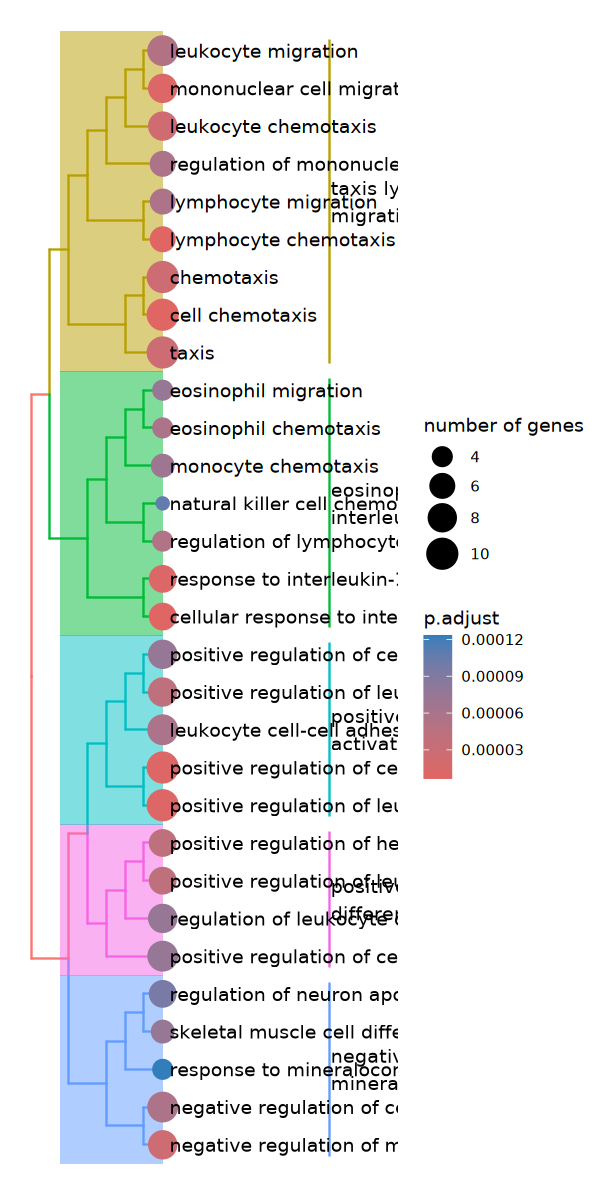

In [23]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego, semData = d)
treeplot(ego2)

Warning message in treeplot.enrichResult(x, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



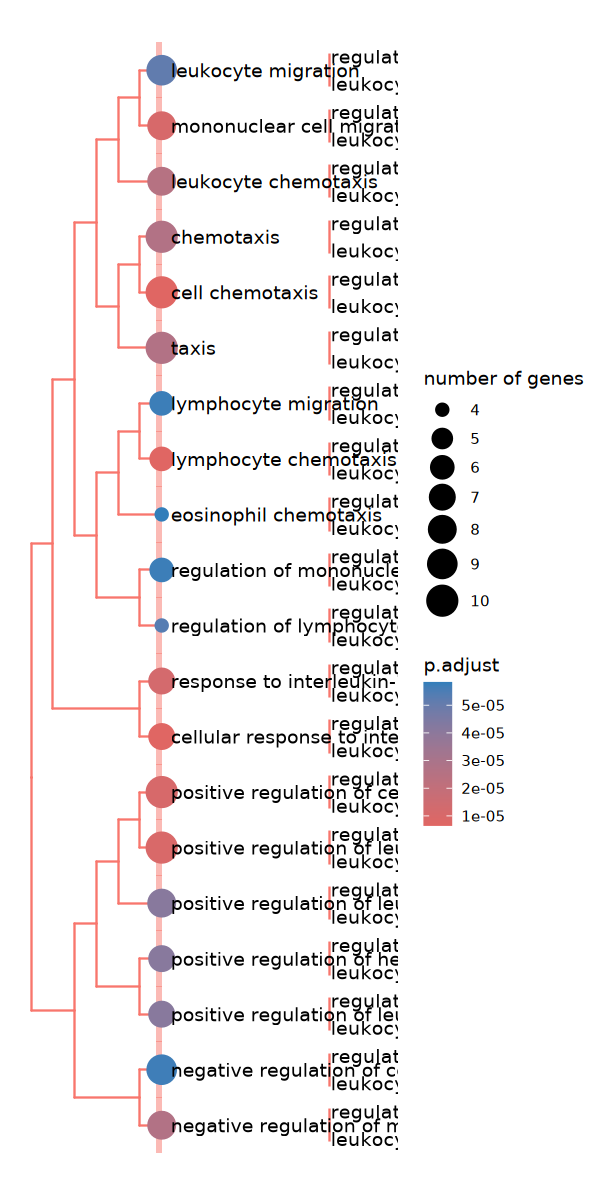

In [24]:
options(repr.plot.height = 10, repr.plot.width = 5)
treeplot(ego2, showCategory = 20, nCluster = 1)

In [25]:
ggsave('figures/go_analysis_myeliod_MP7.pdf', width = 5, height = 7)

In [26]:
ego <- enrichGO(gene          = nmf_modules[[8]],,
                # universe      = rownames(myeloid),
                OrgDb         = org.Hs.eg.db,
                keyType = 'SYMBOL',
                ont           = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
        readable      = TRUE)
head(ego, n=30)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0006898,GO:0006898,receptor-mediated endocytosis,7/46,258/18870,2.795822e-06,0.003629559,0.002856038,MRC1/LYVE1/ITSN1/SIGLEC1/DAB2/CD36/ITGA4,7
GO:0072583,GO:0072583,clathrin-dependent endocytosis,4/46,47/18870,5.104865e-06,0.003629559,0.002856038,ITSN1/SIGLEC1/DAB2/ITGA4,4
GO:0045785,GO:0045785,positive regulation of cell adhesion,8/46,482/18870,1.900848e-05,0.008101944,0.006375280,VAV3/CR1/DAB2/IL15/CD28/CD36/DOCK1/ITGA4,8
GO:0031589,GO:0031589,cell-substrate adhesion,7/46,356/18870,2.279028e-05,0.008101944,0.006375280,LYVE1/SIGLEC1/DAB2/CD36/DOCK1/EDA/ITGA4,7
GO:0002764,GO:0002764,immune response-regulating signaling pathway,7/46,500/18870,1.922481e-04,0.038411588,0.030225419,COLEC12/VAV3/CD200R1/CR1/ESR1/CD28/CD36,7
GO:0030522,GO:0030522,intracellular receptor signaling pathway,6/46,353/18870,2.046235e-04,0.038411588,0.030225419,COLEC12/THRB/ESR1/AHR/DAB2/CD36,6
GO:0006909,GO:0006909,phagocytosis,5/46,237/18870,2.698760e-04,0.038411588,0.030225419,COLEC12/VAV3/IL15/CD36/DOCK1,5
GO:0050670,GO:0050670,regulation of lymphocyte proliferation,5/46,238/18870,2.751692e-04,0.038411588,0.030225419,VAV3/CR1/AHR/IL15/CD28,5
GO:0050864,GO:0050864,regulation of B cell activation,4/46,130/18870,2.804969e-04,0.038411588,0.030225419,VAV3/CR1/AHR/CD28,4


In [11]:
enr_go <- clusterProfiler::simplify(ego)
View(enr_go@result)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0006898,GO:0006898,receptor-mediated endocytosis,7/46,258/18870,2.795822e-06,0.003629559,0.002856038,MRC1/LYVE1/ITSN1/SIGLEC1/DAB2/CD36/ITGA4,7
GO:0072583,GO:0072583,clathrin-dependent endocytosis,4/46,47/18870,5.104865e-06,0.003629559,0.002856038,ITSN1/SIGLEC1/DAB2/ITGA4,4
GO:0045785,GO:0045785,positive regulation of cell adhesion,8/46,482/18870,1.900848e-05,0.008101944,0.006375280,VAV3/CR1/DAB2/IL15/CD28/CD36/DOCK1/ITGA4,8
GO:0031589,GO:0031589,cell-substrate adhesion,7/46,356/18870,2.279028e-05,0.008101944,0.006375280,LYVE1/SIGLEC1/DAB2/CD36/DOCK1/EDA/ITGA4,7
GO:0002764,GO:0002764,immune response-regulating signaling pathway,7/46,500/18870,1.922481e-04,0.038411588,0.030225419,COLEC12/VAV3/CD200R1/CR1/ESR1/CD28/CD36,7
GO:0030522,GO:0030522,intracellular receptor signaling pathway,6/46,353/18870,2.046235e-04,0.038411588,0.030225419,COLEC12/THRB/ESR1/AHR/DAB2/CD36,6
GO:0006909,GO:0006909,phagocytosis,5/46,237/18870,2.698760e-04,0.038411588,0.030225419,COLEC12/VAV3/IL15/CD36/DOCK1,5
GO:0050670,GO:0050670,regulation of lymphocyte proliferation,5/46,238/18870,2.751692e-04,0.038411588,0.030225419,VAV3/CR1/AHR/IL15/CD28,5
GO:0050864,GO:0050864,regulation of B cell activation,4/46,130/18870,2.804969e-04,0.038411588,0.030225419,VAV3/CR1/AHR/CD28,4


preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



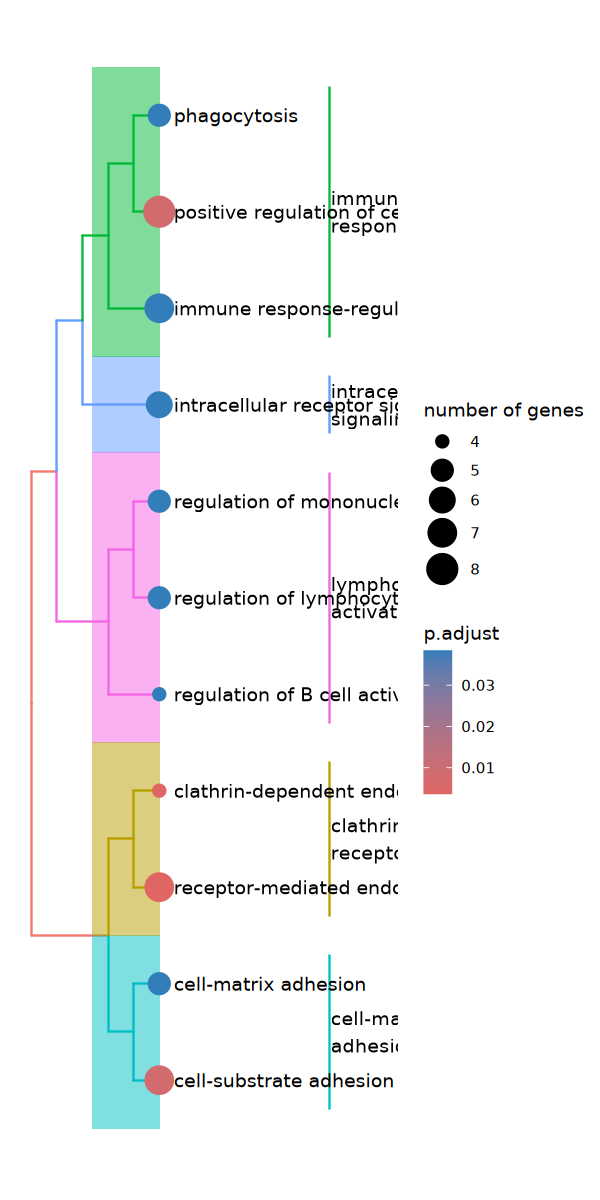

In [27]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego, semData = d)
treeplot(ego2)

Warning message in treeplot.enrichResult(x, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



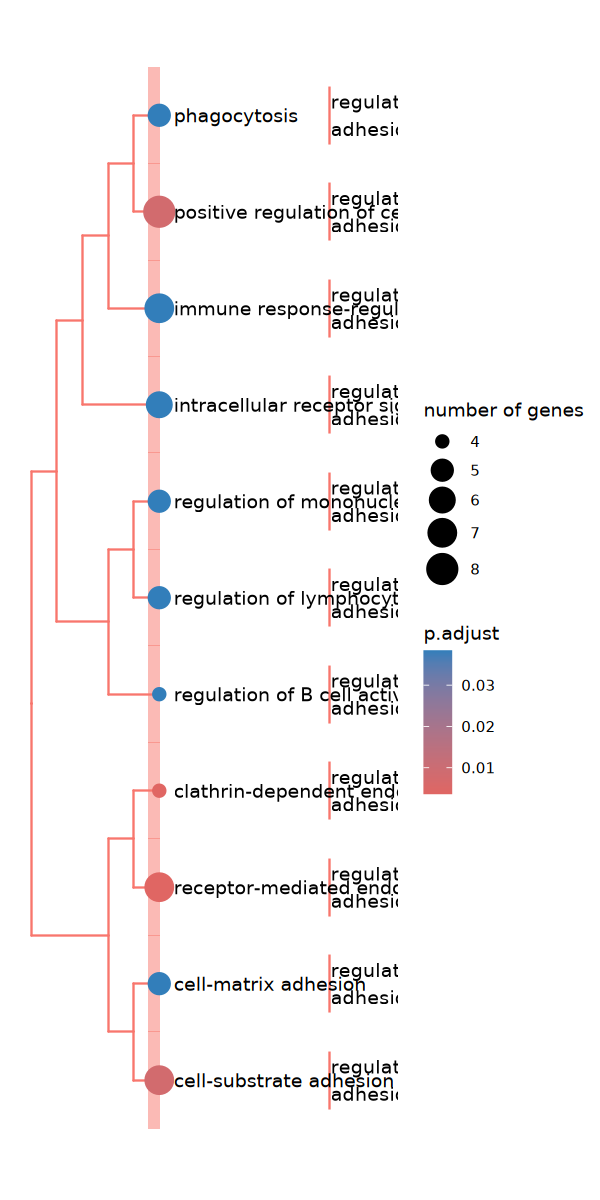

In [28]:
options(repr.plot.height = 10, repr.plot.width = 5)
treeplot(ego2, showCategory = 20, nCluster = 1)

In [29]:
ggsave('figures/go_analysis_myeliod_MP8.pdf', width = 5, height = 3.5)

In [30]:
ego <- enrichGO(gene          = nmf_modules[[9]],,
                # universe      = rownames(myeloid),
                OrgDb         = org.Hs.eg.db,
                keyType = 'SYMBOL',
                ont           = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
        readable      = TRUE)
head(ego, n=30)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0010878,GO:0010878,cholesterol storage,4/48,25/18870,4.481506e-07,0.0006153108,0.0005137222,LPL/MSR1/PPARG/LIPA,4
GO:1905954,GO:1905954,positive regulation of lipid localization,5/48,111/18870,9.003719e-06,0.0061810531,0.0051605526,LPL/EEPD1/MSR1/PPARG/SPP1,5
GO:0010885,GO:0010885,regulation of cholesterol storage,3/48,19/18870,1.454588e-05,0.0066571649,0.0055580577,LPL/MSR1/PPARG,3
GO:0007584,GO:0007584,response to nutrient,5/48,155/18870,4.513941e-05,0.0154941015,0.0129360037,LPL/PPARG/SPP1/ALDH1A2/LIPA,5
GO:0010743,GO:0010743,regulation of macrophage derived foam cell differentiation,3/48,33/18870,7.987734e-05,0.0155242366,0.0129611636,LPL/MSR1/PPARG,3
GO:0097006,GO:0097006,regulation of plasma lipoprotein particle levels,4/48,91/18870,8.372390e-05,0.0155242366,0.0129611636,LPL/MSR1/PLA2G7/LIPA,4
GO:0019915,GO:0019915,lipid storage,4/48,94/18870,9.499645e-05,0.0155242366,0.0129611636,LPL/MSR1/PPARG/LIPA,4
GO:1905952,GO:1905952,regulation of lipid localization,5/48,183/18870,9.918396e-05,0.0155242366,0.0129611636,LPL/EEPD1/MSR1/PPARG/SPP1,5
GO:0048771,GO:0048771,tissue remodeling,5/48,184/18870,1.017612e-04,0.0155242366,0.0129611636,GPNMB/MITF/PPARG/SPP1/LIPA,5


In [15]:
enr_go <- clusterProfiler::simplify(ego)
View(enr_go@result)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0010878,GO:0010878,cholesterol storage,4/48,25/18870,4.481506e-07,0.0006153108,0.0005137222,LPL/MSR1/PPARG/LIPA,4
GO:1905954,GO:1905954,positive regulation of lipid localization,5/48,111/18870,9.003719e-06,0.0061810531,0.0051605526,LPL/EEPD1/MSR1/PPARG/SPP1,5
GO:0007584,GO:0007584,response to nutrient,5/48,155/18870,4.513941e-05,0.0154941015,0.0129360037,LPL/PPARG/SPP1/ALDH1A2/LIPA,5
GO:0010743,GO:0010743,regulation of macrophage derived foam cell differentiation,3/48,33/18870,7.987734e-05,0.0155242366,0.0129611636,LPL/MSR1/PPARG,3
GO:0097006,GO:0097006,regulation of plasma lipoprotein particle levels,4/48,91/18870,8.372390e-05,0.0155242366,0.0129611636,LPL/MSR1/PLA2G7/LIPA,4
GO:0048771,GO:0048771,tissue remodeling,5/48,184/18870,1.017612e-04,0.0155242366,0.0129611636,GPNMB/MITF/PPARG/SPP1/LIPA,5
GO:0071404,GO:0071404,cellular response to low-density lipoprotein particle stimulus,3/48,38/18870,1.224074e-04,0.0162201204,0.0135421559,LPL/CD9/PPARG,3
GO:0055094,GO:0055094,response to lipoprotein particle,3/48,39/18870,1.323715e-04,0.0162201204,0.0135421559,LPL/CD9/PPARG,3
GO:0010742,GO:0010742,macrophage derived foam cell differentiation,3/48,40/18870,1.428490e-04,0.0162201204,0.0135421559,LPL/MSR1/PPARG,3


preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invail

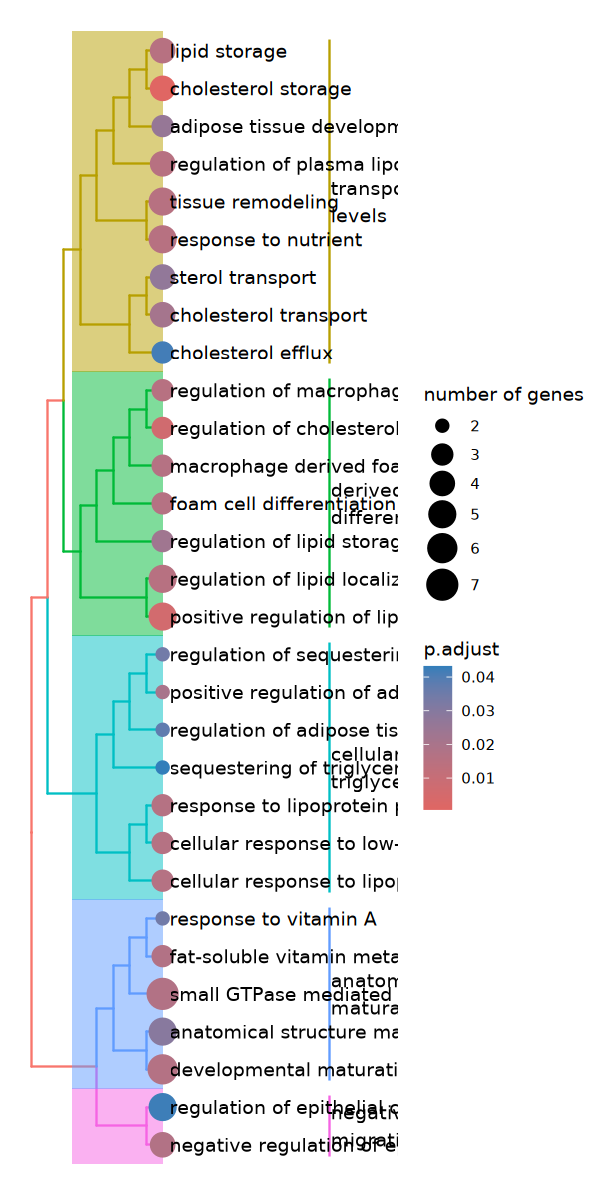

In [31]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego, semData = d)
treeplot(ego2)

Warning message in treeplot.enrichResult(x, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



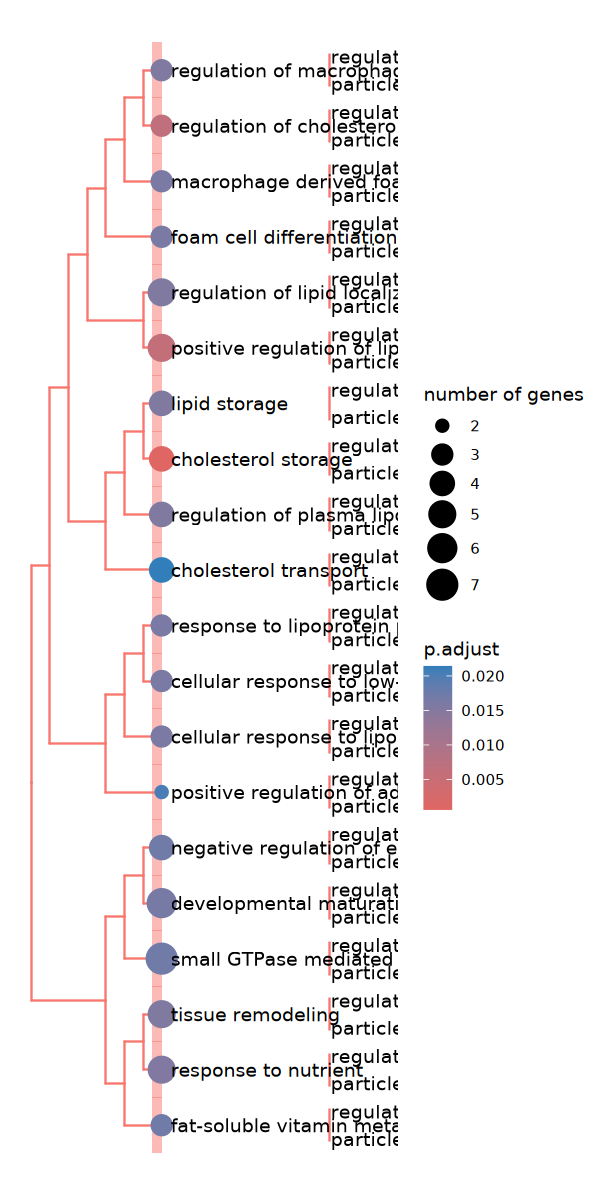

In [32]:
options(repr.plot.height = 10, repr.plot.width = 5)
treeplot(ego2, showCategory = 20, nCluster = 1)

In [33]:
ggsave('figures/go_analysis_myeliod_MP9.pdf', width = 5, height = 7)